In [ ]:
# %%
import numpy as np
from scipy.interpolate import interp1d
import dustpy
import tripodpy
from dustpy import constants as c
from dustpy.utils import Boundary
from dustpylib.substructures.gaps.gaps import duffell2020
from tripodpy.plot import panel

amu = 1.66053886e-24

au = dustpy.constants.au
year = dustpy.constants.year


In [13]:
sim = tripodpy.Simulation()

# Grid Configuration
ri = np.geomspace(2.0, 250, 400) * c.au
sim.grid.ri = ri
sim.ini.grid.mmin = (4./3.*np.pi*1.67*1e-5**3)

# Gas Parameters
sim.ini.gas.alpha = 0.001
sim.ini.gas.SigmaRc = 60.0 * au
sim.ini.gas.SigmaExp = -0.85
sim.ini.gas.mu = 2.33*amu

# Dust Parameters
sim.ini.dust.vFrag = 100.0
sim.ini.dust.d2gRatio = 0.01
sim.ini.dust.allowDriftingParticles = False

# Stellar Parameters (from Baraffe first snapshot)
sim.ini.star.M = 1.0 * dustpy.constants.M_sun
sim.ini.star.R = 3.096 * dustpy.constants.R_sun
sim.ini.star.T = 4397.0

sim.ini.gas.Mdisk = 0.05*sim.ini.star.M

sim.initialize()


In [ ]:

sim.t.snapshots = np.geomspace(1e2*year, 1e5*year, 20)
# Turn off gas evolution
sim.gas.nu[:] = 0.0
sim.gas.nu.updater = None

# add the planet and modify the disk to have a gap according to Duffell 2020
a_p =  5.2*au
q_p = 1e-3
f_h = interp1d(sim.grid.r, sim.gas.Hp/sim.grid.r)
h = f_h(a_p)
alpha_mod = duffell2020(sim.grid.r, a_p, q_p, h, sim.ini.gas.alpha)
sim.gas.Sigma[...]  *= alpha_mod/sim.ini.gas.alpha
sim.dust.Sigma[...] *= (alpha_mod/sim.ini.gas.alpha)[:, None]
sim.components.Default.gas.Sigma = sim.gas.Sigma.copy()

sim.gas.rho.update()
sim.gas.P.update()

#set boundaies for s.max
sim.dust.s.boundary.inner = Boundary(
            sim.grid.r,
            sim.grid.ri,
            sim.dust.Sigma[...,1]*sim.dust.s.max,
            condition="const_pow")

sim.dust.s.boundary.outer = Boundary(
            sim.grid.r,
            sim.grid.ri,
            sim.dust.Sigma[...,1]*sim.dust.s.max,
            condition="const_pow")


sim.update()



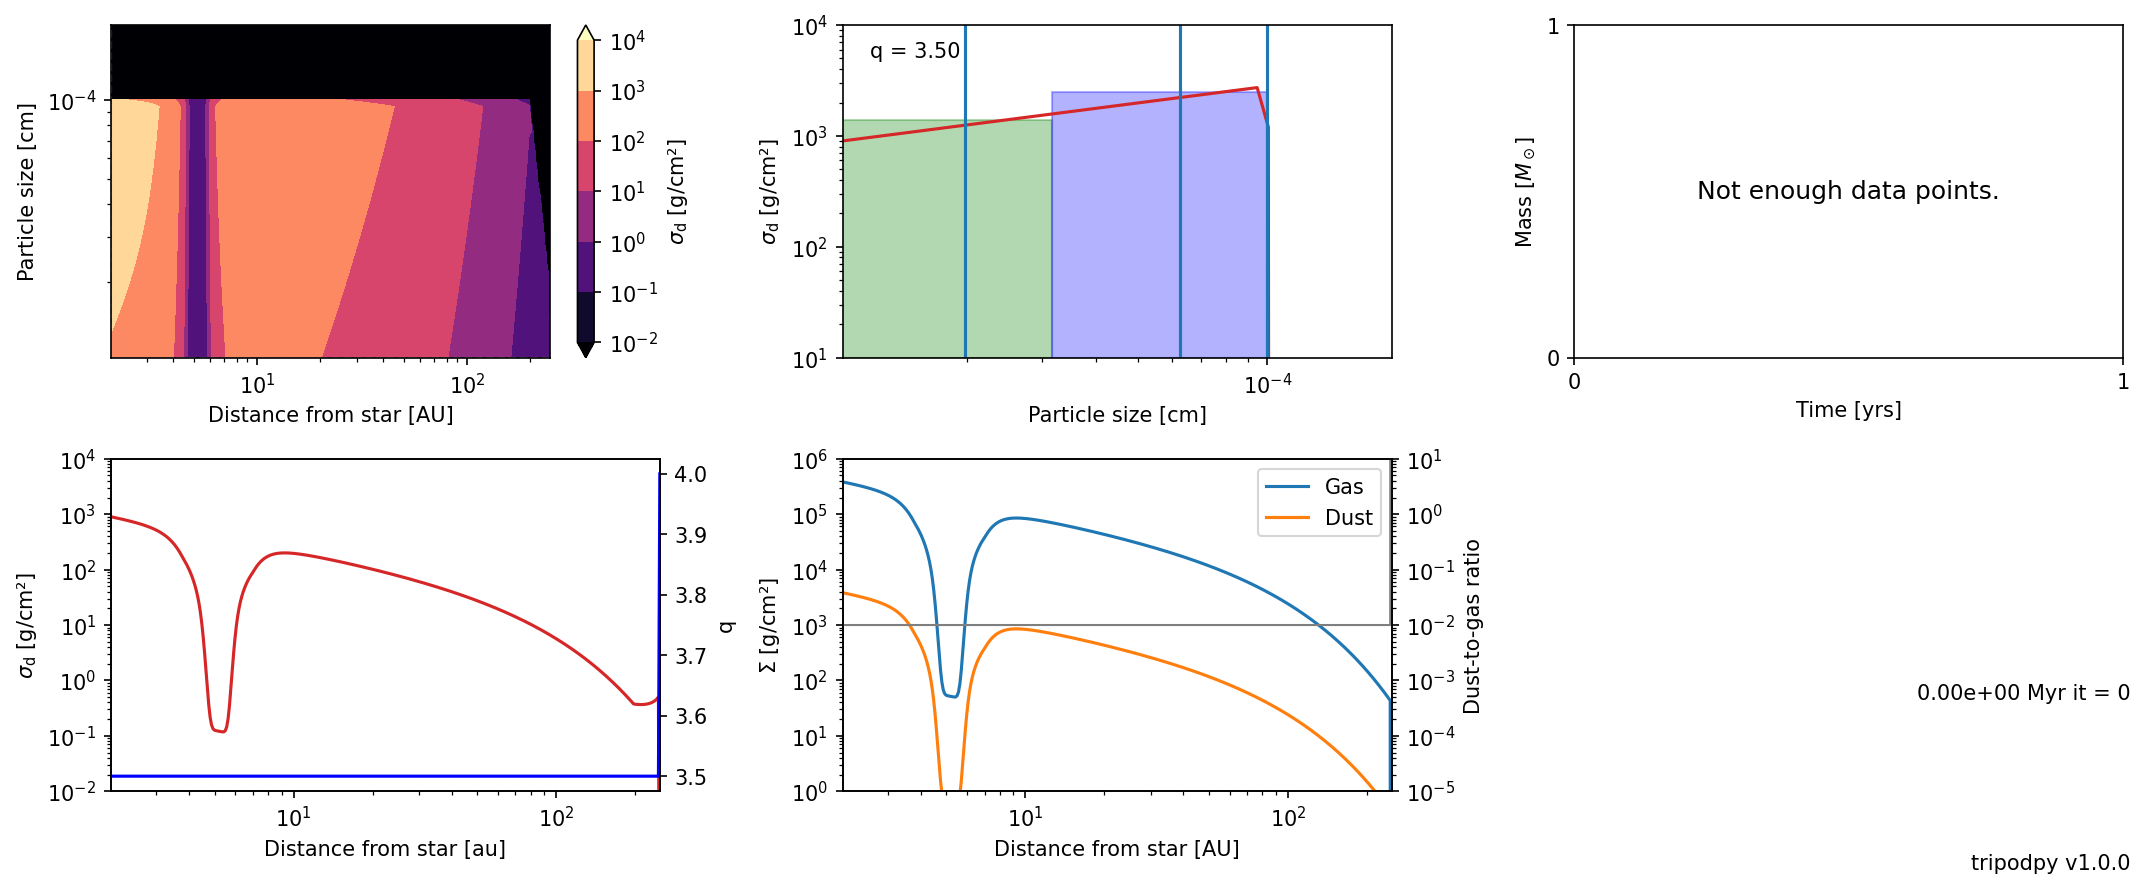

In [17]:
panel(sim,show_limits=False)

In [ ]:
# Write data
sim.writer.datadir = "data_duffle"
sim.writer.overwrite = True

sim.run()


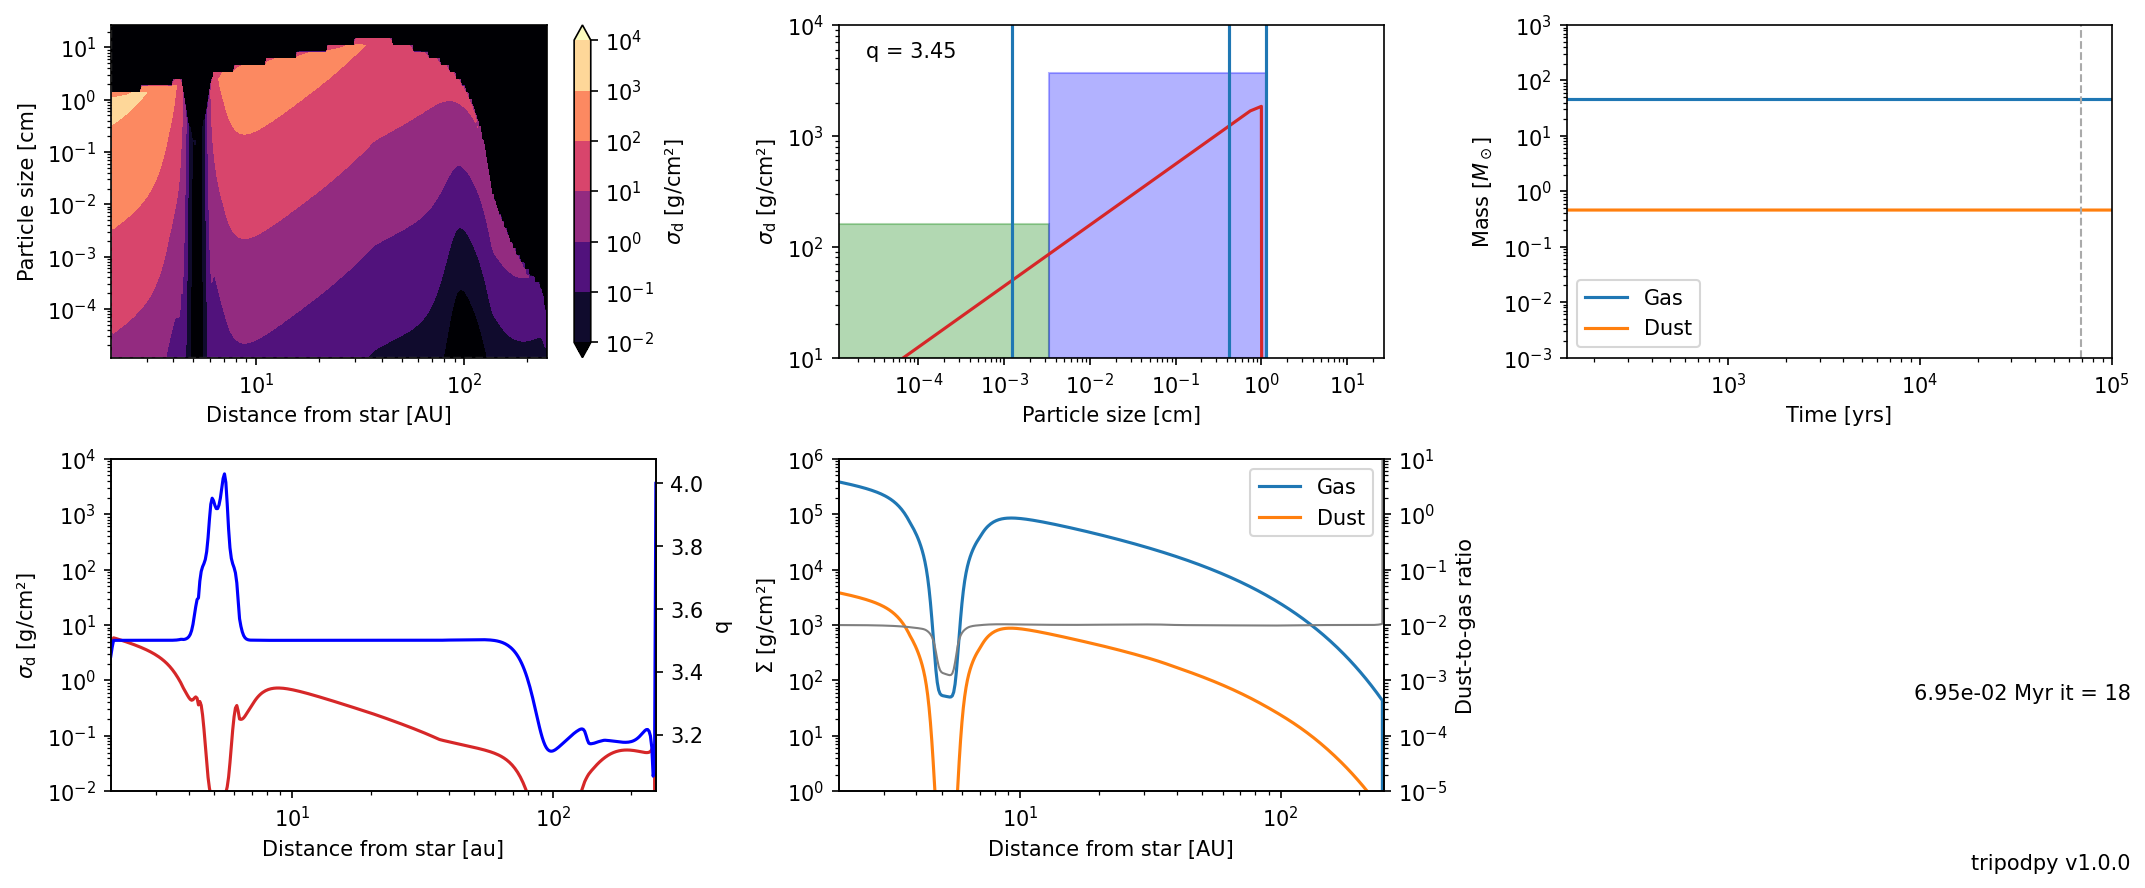

In [18]:

panel("data_duffle",show_limits=False,it=18)
